# Questão 5 - Dimensão de Calendário e Vendas por Dia da Semana

**Premissas obrigatórias:**
- Período: da menor data de venda até a data atual
- Considerar apenas lojas físicas (`channel = pos`)
- Dias sem registro = venda 0
- Média por dia da semana considera todos os dias do calendário
- Nomes dos dias em português

In [1]:
import pandas as pd
from src.db import get_engine

engine = get_engine()


## Questão 5.1 - SQL: calendário + LEFT JOIN com vendas

(ver `sql/queries/q5_calendario_vendas.sql`)


In [2]:
calendario_query = """
WITH calendario AS (
    SELECT generate_series(
        (SELECT MIN(created_at)::date FROM orders),
        CURRENT_DATE,
        '1 day'::interval
    )::date AS data
),

vendas_pos AS (
    SELECT
        created_at::date AS data,
        SUM(total)        AS venda_dia
    FROM orders
    WHERE channel = 'pos'
    GROUP BY created_at::date
),

calendario_vendas AS (
    SELECT
        c.data,
        COALESCE(v.venda_dia, 0) AS venda_dia,
        CASE EXTRACT(DOW FROM c.data)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda-feira'
            WHEN 2 THEN 'Terça-feira'
            WHEN 3 THEN 'Quarta-feira'
            WHEN 4 THEN 'Quinta-feira'
            WHEN 5 THEN 'Sexta-feira'
            WHEN 6 THEN 'Sábado'
        END AS dia_semana
    FROM calendario c
    LEFT JOIN vendas_pos v ON v.data = c.data
)

SELECT
    dia_semana,
    ROUND(AVG(venda_dia), 2) AS media_venda,
    COUNT(*)                 AS qtd_dias_no_calendario
FROM calendario_vendas
GROUP BY dia_semana
ORDER BY media_venda ASC;
"""

media_por_dia_sql = pd.read_sql(calendario_query, engine)
media_por_dia_sql

,dia_semana,media_venda,qtd_dias_no_calendario
0,Quinta-feira,151309.08,345
1,Segunda-feira,151858.64,345
2,Domingo,154408.52,345
3,Sábado,159288.41,345
4,Terça-feira,159999.97,345
5,Sexta-feira,163625.58,345
6,Quarta-feira,169054.47,346


## Validação cruzada (pandas)

Reproduzindo a mesma lógica em pandas, incluindo o comparativo com o erro do estagiário (média calculada só sobre os dias com venda, ignorando os dias zerados).

In [3]:
orders = pd.read_sql("SELECT id, channel, total, created_at FROM orders", engine)
orders['created_at'] = pd.to_datetime(orders['created_at'])
orders['data'] = orders['created_at'].dt.date

pos = orders[orders['channel'] == 'pos']

dias_pt = {0: 'Segunda-feira', 1: 'Terça-feira', 2: 'Quarta-feira', 3: 'Quinta-feira',
           4: 'Sexta-feira', 5: 'Sábado', 6: 'Domingo'}

# Agregação diária real (SUM de total por dia, só lojas físicas)
vendas_diarias = pos.groupby('data')['total'].sum().reset_index()
vendas_diarias['dia_semana'] = pd.to_datetime(vendas_diarias['data']).dt.dayofweek.map(dias_pt)

# ERRO DO ESTAGIÁRIO: média só sobre os dias que existem na tabela (sem zero-fill)
media_estagiario = vendas_diarias.groupby('dia_semana')['total'].mean().round(2).sort_values()

# CORRETO: calendário completo (min created_at até hoje), dias sem venda = 0
calendario = pd.date_range(start=orders['created_at'].min().date(), end=pd.Timestamp.today().date(), freq='D')
calendario_df = pd.DataFrame({'data': calendario.date})
calendario_df = calendario_df.merge(vendas_diarias[['data', 'total']], on='data', how='left')
calendario_df['total'] = calendario_df['total'].fillna(0)
calendario_df['dia_semana'] = pd.to_datetime(calendario_df['data']).dt.dayofweek.map(dias_pt)

media_correta_pandas = calendario_df.groupby('dia_semana')['total'].mean().round(2).sort_values()

comparacao = pd.DataFrame({
    'media_correta_pandas': media_correta_pandas,
    'media_estagiario_errada': media_estagiario
}).sort_values('media_correta_pandas')

print("Comparação: média correta (com dias zerados) vs erro do estagiário (sem dias zerados)")
display(comparacao)

# Confere se a média correta em pandas bate com o resultado do SQL
media_por_dia_sql_indexed = media_por_dia_sql.set_index('dia_semana')['media_venda']
diferenca_sql_pandas = (media_por_dia_sql_indexed - media_correta_pandas).abs().max()
print(f"\nMaior diferença entre SQL e pandas: {diferenca_sql_pandas}")

pior_dia = media_correta_pandas.idxmin()
print(f"\nPior dia da semana (média correta): {pior_dia} — R$ {media_correta_pandas.min():.2f}")


Comparação: média correta (com dias zerados) vs erro do estagiário (sem dias zerados)


,media_correta_pandas,media_estagiario_errada
dia_semana,,
Quinta-feira,151309.08,166238.38
Segunda-feira,151858.64,161335.26
Domingo,154408.52,162974.19
Sábado,159288.41,169980.98
Terça-feira,159999.97,169841.38
Sexta-feira,163625.58,174987.87
Quarta-feira,169114.45,178481.99



Maior diferença entre SQL e pandas: 59.98000000001048

Pior dia da semana (média correta): Quinta-feira — R$ 151309.08


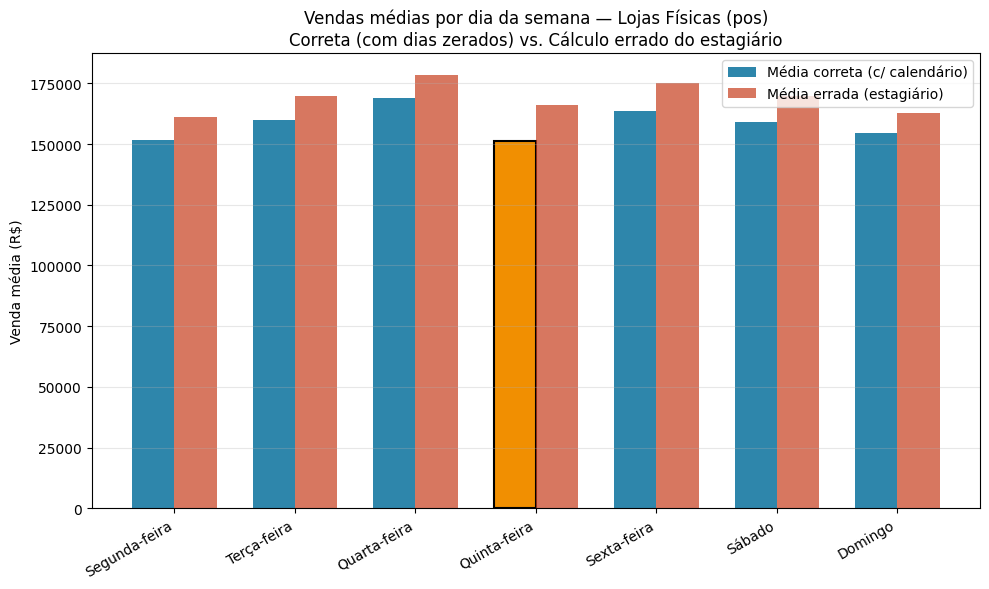

In [5]:
import matplotlib.pyplot as plt

ordem_dias = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira',
              'Sexta-feira', 'Sábado', 'Domingo']

media_correta_ordenada = media_correta_pandas.reindex(ordem_dias)
media_estagiario_ordenada = media_estagiario.reindex(ordem_dias)

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(ordem_dias))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], media_correta_ordenada.values, width,
               label='Média correta (c/ calendário)', color='#2E86AB')
bars2 = ax.bar([i + width/2 for i in x], media_estagiario_ordenada.values, width,
               label='Média errada (estagiário)', color='#C73E1D', alpha=0.7)

# Destaca o pior dia real
pior_idx = ordem_dias.index(pior_dia)
bars1[pior_idx].set_color('#F18F01')
bars1[pior_idx].set_edgecolor('black')
bars1[pior_idx].set_linewidth(1.5)

ax.set_xticks(x)
ax.set_xticklabels(ordem_dias, rotation=30, ha='right')
ax.set_ylabel('Venda média (R$)')
ax.set_title('Vendas médias por dia da semana — Lojas Físicas (pos)\n'
              'Correta (com dias zerados) vs. Cálculo errado do estagiário')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Resultado: pior dia da semana em média de vendas

In [4]:
print(f"O pior dia da semana em vendas médias nas lojas físicas é: {pior_dia}")
print(f"Média correta: R$ {media_correta_pandas.min():,.2f}")
print(f"Média que o estagiário calculou (errada) para o mesmo dia: R$ {media_estagiario[pior_dia]:,.2f}")
print()
print("O estagiário havia apontado Domingo como o melhor dia, mas isso ignorava")
print("os dias sem venda registrada, inflando artificialmente a média de vários dias.")

O pior dia da semana em vendas médias nas lojas físicas é: Quinta-feira
Média correta: R$ 151,309.08
Média que o estagiário calculou (errada) para o mesmo dia: R$ 166,238.38

O estagiário havia apontado Domingo como o melhor dia, mas isso ignorava
os dias sem venda registrada, inflando artificialmente a média de vários dias.


## Questão 5.2 - Explique

**1. Por que é necessário utilizar uma tabela de datas (calendário) em vez de agrupar diretamente a tabela de vendas?**

Porque agrupar diretamente `orders` só enxerga os dias em que houve pelo menos uma venda. Dias em que a loja física esteve aberta mas não vendeu nada simplesmente não existem na tabela, então ficam de fora do cálculo — sub-representando a real frequência de vendas zero daquele dia da semana. A tabela de calendário garante que todo dia do período apareça exatamente uma vez, independente de ter venda ou não.

**2. O que aconteceria com a média de vendas se um dia da semana tivesse muitos dias sem nenhuma venda registrada?**

A média calculada sem o calendário ficaria artificialmente inflada: o denominador (quantidade de dias considerados) diminui mais rápido que o numerador (soma de vendas), fazendo aquele dia da semana parecer mais forte do que é na realidade. Foi exatamente esse o engano do estagiário — ele concluiu que Domingo era um ótimo dia de vendas, quando na verdade, após contabilizar corretamente os dias sem venda, Quinta-feira se revela o pior dia (R$ 151.309,08 de média), não Domingo.